<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-50] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2853 acc 0.460 | val loss 1.0818 acc 0.493 *


[ResNet-50] Epoch   2/100 | LR: 1.00e-04 | train loss 1.0337 acc 0.487 | val loss 0.8344 acc 0.576 *


[ResNet-50] Epoch   3/100 | LR: 1.00e-04 | train loss 0.8149 acc 0.583 | val loss 0.8569 acc 0.562


[ResNet-50] Epoch   4/100 | LR: 1.00e-04 | train loss 0.7047 acc 0.682 | val loss 0.5817 acc 0.764 *


...

[ResNet-50] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0807 acc 0.965 | val loss 0.4445 acc 0.852


[ResNet-50] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0702 acc 0.972 | val loss 0.4309 acc 0.857


[ResNet-50] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0603 acc 0.970 | val loss 0.4202 acc 0.862


[ResNet-50] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0766 acc 0.967 | val loss 0.4333 acc 0.857


[ResNet-50] Epoch  20/100 | LR: 1.00e-05 | train loss 0.0501 acc 0.977 | val loss 0.4239 acc 0.872

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 20.

[ResNet-50] Restored best checkpoint (val loss = 0.4118)


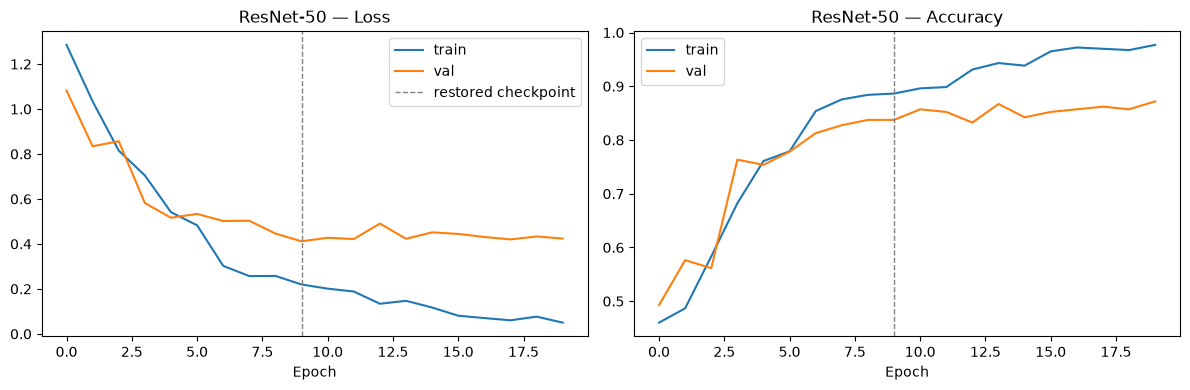

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.639


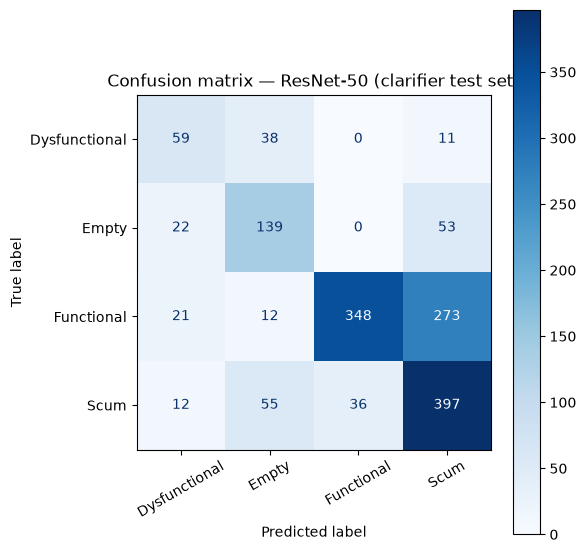

               precision    recall  f1-score   support

Dysfunctional      0.518     0.546     0.532       108
        Empty      0.570     0.650     0.607       214
   Functional      0.906     0.532     0.671       654
         Scum      0.541     0.794     0.643       500

     accuracy                          0.639      1476
    macro avg      0.634     0.630     0.613      1476
 weighted avg      0.705     0.639     0.642      1476



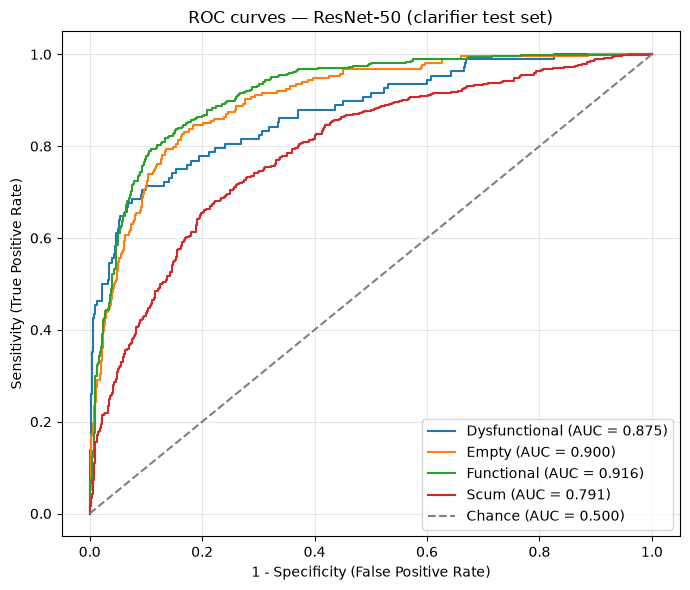

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.875
  Empty          : 0.900
  Functional     : 0.916
  Scum           : 0.791

Mean AUC (over 4/4 classes with test examples): 0.870


(np.float64(0.6388888888888888),
 {'Dysfunctional': 0.8749052414988088,
  'Empty': 0.9002473451130826,
  'Functional': 0.9159300430813189,
  'Scum': 0.7905737704918032})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_CapeFlats.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
